In [1]:
from analyses.data_loader import explode_spike_data
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

/home/connorlab/miniconda3/envs/neural_analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-07 15:47:12.721343: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/Zombies_marg_ols_on_single_neurons.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.05]
print(significant_results.shape)
print(significant_results['NeuronID'].nunique())


(930, 7)
286


In [5]:
significant_results

,NeuronID,Behavior,Source_Monkey,Model,R-squared,coef,p_value
2451,ER_2023-12-07_2_Channel.C_012,AffiliationTo,94B,ols,0.499564,-0.248793,0.049970
14262,Unknown_2023-12-18_1_Channel.C_029_Unit 1,AgonismTo,143H,ols,0.499632,1.586179,0.049947
3438,AMG_2023-10-04_2_Channel.C_013,AffiliationFrom,7124,ols,0.499718,-1.099396,0.049919
12838,ER_2023-10-27_3_Channel.C_013,AgonismTo,110E,ols,0.499883,-0.522719,0.049864
13328,ER_2023-11-22_4_Channel.C_017,AgonismTo,151J,ols,0.499941,-0.593653,0.049845
...,...,...,...,...,...,...,...
2836,Unknown_2023-12-18_3_Channel.C_003,AffiliationTo,69X,ols,0.912103,0.494895,0.000220
14956,AMG_2023-10-04_2_Channel.C_020_Unit 2,AgonismFrom,87J,ols,0.924980,0.815945,0.000136
5707,Unknown_2023-12-18_3_Channel.C_003,AffiliationFrom,69X,ols,0.925018,0.498386,0.000136
8458,ER_2023-12-14_4_Channel.C_004,SubmissionTo,87J,ols,0.925692,0.329421,0.000132


/home/connorlab/miniconda3/envs/neural_analysis/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


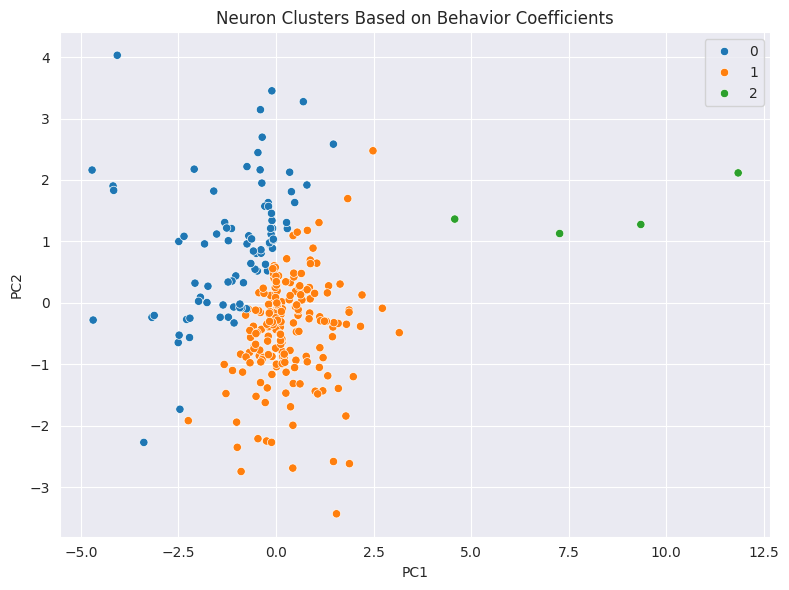

In [12]:
df= significant_results
# 뉴런별로 Behavior마다 R²가 가장 높은 회귀 하나만 선택
best_coef_df = (
    df[df['p_value'] < 0.05]
    .sort_values('R-squared', ascending=False)
    .drop_duplicates(subset=['NeuronID', 'Behavior'])
)

pivot_df = best_coef_df.pivot(index='NeuronID', columns='Behavior', values='coef').fillna(0)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

scaled = StandardScaler().fit_transform(pivot_df)
reduced = PCA(n_components=2).fit_transform(scaled)
clusters = KMeans(n_clusters=3, random_state=42).fit_predict(reduced)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=clusters, palette='tab10')
plt.title("Neuron Clusters Based on Behavior Coefficients")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


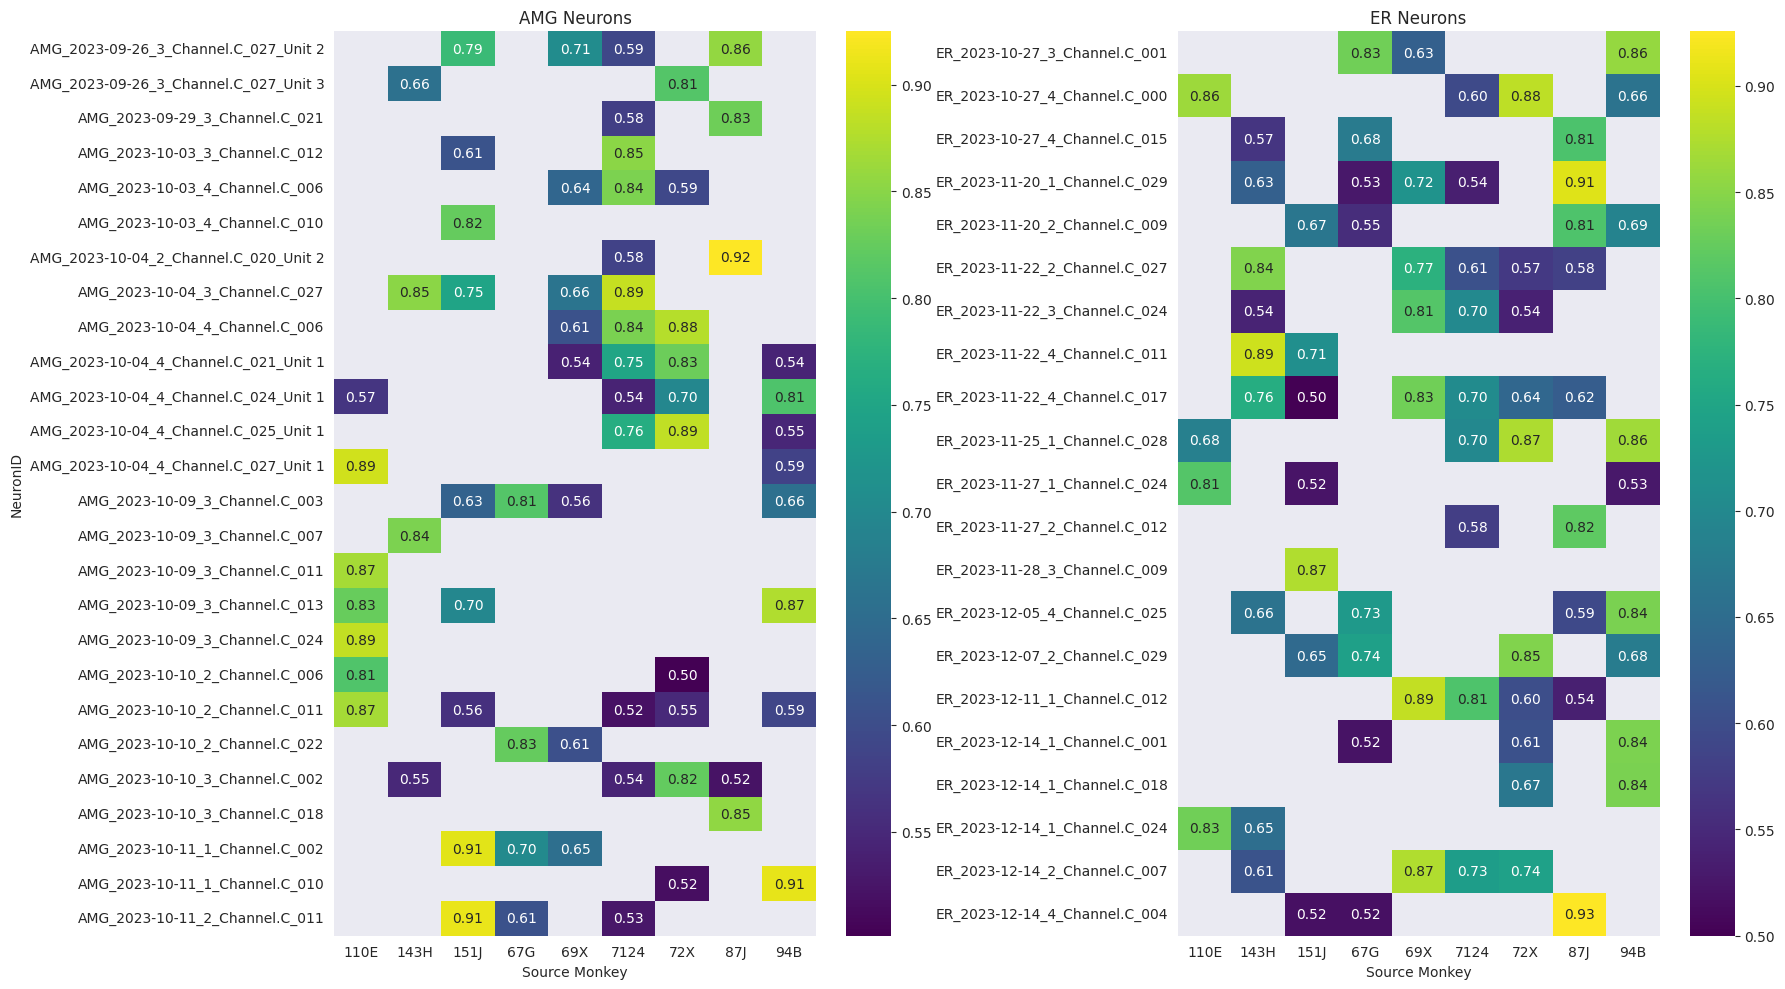

In [3]:
top_n = 50  # 또는 10~15
top_neurons = significant_results.groupby('NeuronID')['R-squared'].max().nlargest(top_n).index
filtered_df = significant_results[significant_results['NeuronID'].isin(top_neurons)]
amg_df = filtered_df[filtered_df['NeuronID'].str.startswith('AMG')]
er_df = filtered_df[filtered_df['NeuronID'].str.startswith('ER')]

fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharex=True)

# AMG
heatmap_amg = amg_df.pivot_table(index='NeuronID', columns='Source_Monkey', values='R-squared', aggfunc='max')
sns.heatmap(heatmap_amg, cmap='viridis', annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("AMG Neurons")
axes[0].set_xlabel("Source Monkey")
axes[0].set_ylabel("NeuronID")

# ER
heatmap_er = er_df.pivot_table(index='NeuronID', columns='Source_Monkey', values='R-squared', aggfunc='max')
sns.heatmap(heatmap_er, cmap='viridis', annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("ER Neurons")
axes[1].set_xlabel("Source Monkey")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

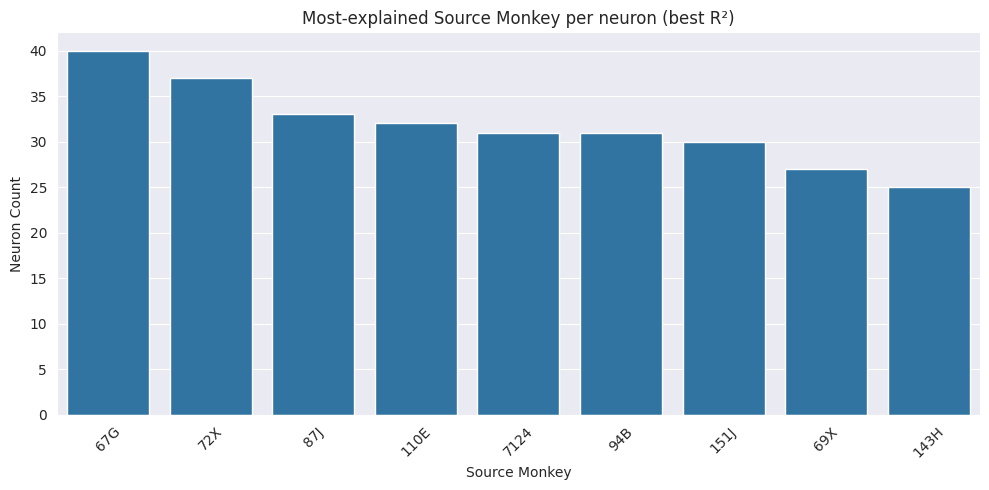

In [4]:
best_monkey_df = significant_results.sort_values('R-squared', ascending=False).drop_duplicates('NeuronID')
plt.figure(figsize=(10, 5))
sns.countplot(data=best_monkey_df, x='Source_Monkey', order=best_monkey_df['Source_Monkey'].value_counts().index)
plt.title("Most-explained Source Monkey per neuron (best R²)")
plt.xlabel("Source Monkey")
plt.ylabel("Neuron Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()